<a href="https://colab.research.google.com/github/SoumyadeepChattopadhyay2004/IPL-WIN-PREDICTOR/blob/main/IPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [103]:
df = pd.read_csv("/content/IPL.csv", low_memory=False)

print(df.shape)
df.head()

(278205, 64)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [104]:
df = df[df['innings'] == 2]

In [105]:
df['current_score'] = df['team_runs']

In [106]:
df['runs_left'] = df['runs_target'] - df['current_score']

In [107]:
df['balls_left'] = 120 - df['ball_no']
df['balls_left'] = df['balls_left'].clip(lower=0)

In [108]:
df['wickets_left'] = 10 - df['team_wicket']

In [109]:
df['overs_completed'] = df['ball_no'] / 6

In [110]:
df['current_run_rate'] = df['current_score'] / df['overs_completed']
df['current_run_rate'] = df['current_run_rate'].replace([np.inf],0)

In [111]:
df['required_run_rate'] = (df['runs_left'] * 6) / df['balls_left']
df['required_run_rate'] = df['required_run_rate'].replace([np.inf],0)

In [112]:
df['result'] = df['win_outcome'].apply(
    lambda x: 1 if 'runs' in str(x) or 'wickets' in str(x) else 0
)

In [113]:
model_df = df[[
'batting_team',
'bowling_team',
'venue',
'runs_left',
'balls_left',
'wickets_left',
'current_run_rate',
'required_run_rate',
'result'
]]

In [114]:
model_df = model_df.dropna()

In [115]:
X = model_df.drop('result', axis=1)
y = model_df['result']

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [117]:
categorical_features = ['batting_team','bowling_team','venue']

transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [118]:
model = Pipeline([
    ('transformer', transformer),
    ('model', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['batting_team',
                                                   'bowling_team',
                                                   'venue'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [119]:
print(df['result'].value_counts())

result
1    132007
0      1896
Name: count, dtype: int64


In [120]:
print(df['result'].value_counts())

result
1    132007
0      1896
Name: count, dtype: int64


In [121]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.9868936932900191
              precision    recall  f1-score   support

           0       0.72      0.08      0.14       368
           1       0.99      1.00      0.99     26413

    accuracy                           0.99     26781
   macro avg       0.85      0.54      0.57     26781
weighted avg       0.98      0.99      0.98     26781



In [122]:
sample = X_test.iloc[0:1]

prob = model.predict_proba(sample)

print("Lose Probability:", prob[0][0])
print("Win Probability:", prob[0][1])

Lose Probability: 1.4621447212981309e-05
Win Probability: 0.999985378552787


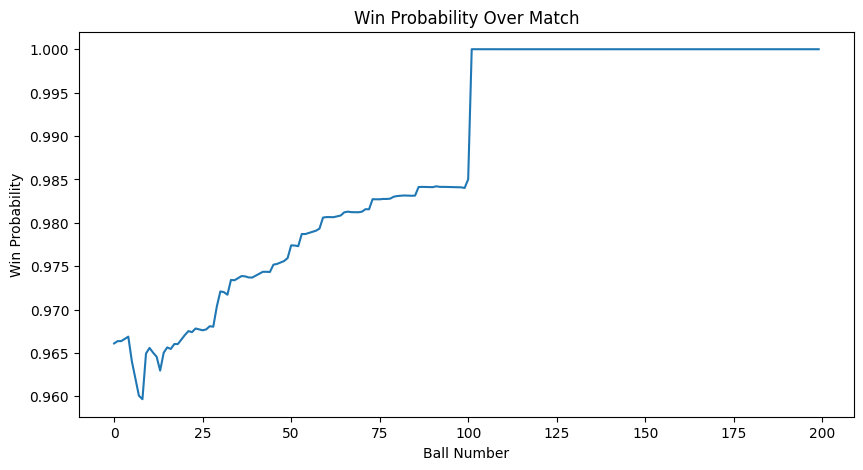

In [123]:
match_example = model_df.iloc[:200]

probs = model.predict_proba(
    match_example.drop('result',axis=1)
)[:,1]

plt.figure(figsize=(10,5))

plt.plot(probs)

plt.title("Win Probability Over Match")

plt.xlabel("Ball Number")

plt.ylabel("Win Probability")

plt.show()

In [124]:
feature_names = model.named_steps['transformer'].get_feature_names_out()

coefficients = model.named_steps['model'].coef_[0]

importance = pd.Series(coefficients, index=feature_names)

importance.sort_values().tail(10)

,0
"encoder__venue_Wankhede Stadium, Mumbai",1.956460
encoder__bowling_team_Deccan Chargers,2.016537
encoder__venue_Sharjah Cricket Stadium,2.140117
"encoder__venue_Punjab Cricket Association Stadium, Mohali",2.255282
encoder__venue_Sawai Mansingh Stadium,2.286745
encoder__venue_Feroz Shah Kotla,2.693494
encoder__batting_team_Delhi Daredevils,2.714542
encoder__venue_Eden Gardens,3.055832
encoder__bowling_team_Sunrisers Hyderabad,3.360997
encoder__bowling_team_Chennai Super Kings,4.535591
